In [13]:
import pandas as pd

df = pd.read_csv("combinedWeekly_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True) #re-indexes at zero

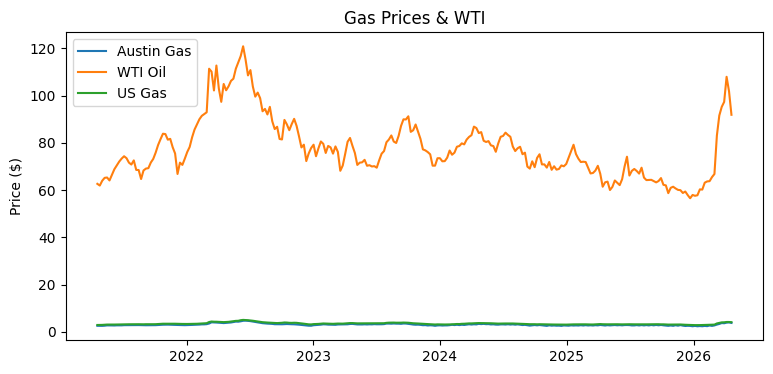

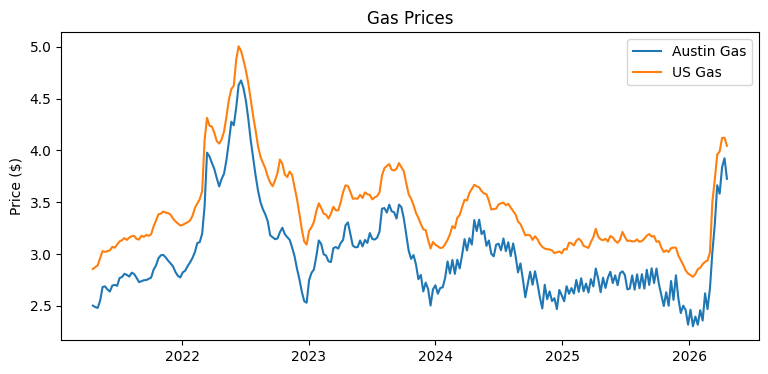

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))

plt.plot(df["date"], df["gas_price"], label="Austin Gas")
plt.plot(df["date"], df["wti_price"], label="WTI Oil")
plt.plot(df["date"], df["national_gas_price"], label="US Gas")

plt.legend()
plt.title("Gas Prices & WTI")
plt.ylabel("Price ($)")
plt.show()

plt.figure(figsize=(9,4))

plt.plot(df["date"], df["gas_price"], label="Austin Gas")
plt.plot(df["date"], df["national_gas_price"], label="US Gas")

plt.legend()
plt.title("Gas Prices")
plt.ylabel("Price ($)")
plt.show()

Note the increase in austin gas price volitility after late 2023, that's what we're investigating here

In [15]:
gas = pd.read_csv("austin_gas_full.csv")
gas["date"] = pd.to_datetime(gas["date"])
gas = gas.sort_values("date").reset_index(drop=True)

print(gas.head())
print(gas.tail())
print(gas.shape)

        date  gas_price
0 2021-04-13      2.505
1 2021-04-14      2.509
2 2021-04-15      2.504
3 2021-04-16      2.499
4 2021-04-17      2.499
           date  gas_price
1549 2026-04-22      3.549
1550 2026-04-23      3.539
1551 2026-04-24      3.524
1552 2026-04-25      3.519
1553 2026-04-26      3.494
(1554, 2)


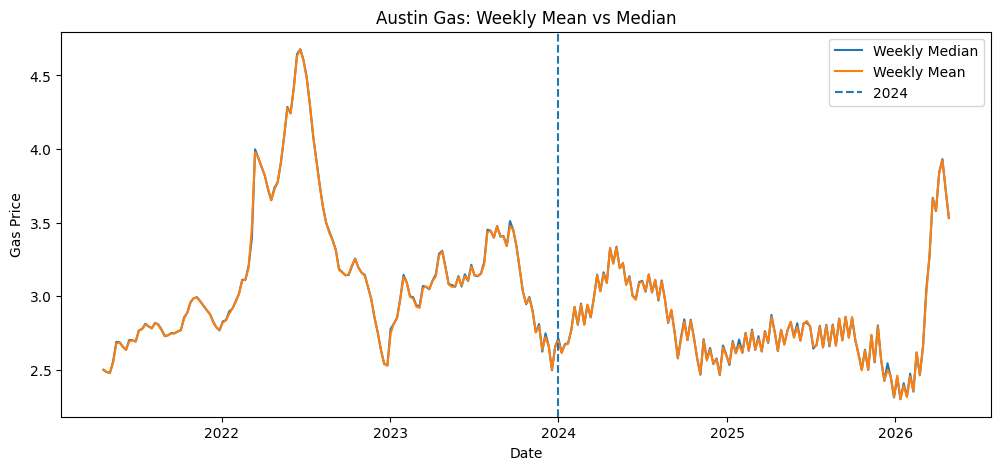

In [5]:
gas_w_mean = gas.set_index("date").resample("W-MON")["gas_price"].mean().reset_index()
gas_w_median = gas.set_index("date").resample("W-MON")["gas_price"].median().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(gas_w_median["date"], gas_w_median["gas_price"], label="Weekly Median")
plt.plot(gas_w_mean["date"], gas_w_mean["gas_price"], label="Weekly Mean")
plt.axvline(pd.to_datetime("2024-01-01"), linestyle="--", label="2024")
plt.legend()
plt.title("Austin Gas: Weekly Mean vs Median")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.show()

In [6]:
gas["date_diff"] = gas["date"].diff()

gas["date_diff"].value_counts().head(10)

date_diff
1 days    1273
2 days     276
3 days       2
4 days       2
Name: count, dtype: int64

In [7]:
gas["year"] = gas["date"].dt.year

gas.groupby("year")["date_diff"].value_counts().unstack().fillna(0)

date_diff,1 days,2 days,3 days,4 days
year,,,,
2021,177.0,41.0,1.0,0.0
2022,238.0,58.0,1.0,2.0
2023,263.0,51.0,0.0,0.0
2024,258.0,54.0,0.0,0.0
2025,255.0,55.0,0.0,0.0
2026,82.0,17.0,0.0,0.0


The Austin gas dataset is consistently sampled over time, with mostly daily observations and some expected gaps (like weekends). There is no evidence of a change in data frequency or reporting behavior after 2024.

Notably, Austin gas and WTI prices skip weekends, so the data is effectively business-day frequency. This isn’t a major issue, but it does mean that some price changes (like Friday to Monday) reflect multiple days, which can slightly inflate volatility. Resampling to weekly data helps address this by making the time intervals consistent.

In [17]:
gas["d_gas"] = gas["gas_price"].diff()

In [18]:
pre = gas[gas["date"] < "2024-01-01"]["d_gas"]
post = gas[gas["date"] >= "2024-01-01"]["d_gas"]

print("Pre-2024 std:", pre.std())
print("Post-2024 std:", post.std())

Pre-2024 std: 0.02693138375044421
Post-2024 std: 0.05555713781072451


Notice that volitilty, as meaured by std, doubles post 2024-01-01 as previously seen.

In [24]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import breaks_cusumolsresid

# make sure the change variable exists
gas["d_gas"] = gas["gas_price"].diff()

# drop missing values from first difference
y = gas["d_gas"].dropna()

# simple time trend
x = sm.add_constant(range(len(y)))

# fit model
model = sm.OLS(y, x).fit()

stat, pval, crit = breaks_cusumolsresid(model.resid)

print("Test stat:", round(stat, 4))
print("p-value:", round(pval, 4))
print("Critical values:", crit)

Test stat: 1.1801
p-value: 0.1234
Critical values: [(1, 1.63), (5, 1.36), (10, 1.22)]


The CUSUM test returns a p-value of about 0.12, so I fail to reject the null of parameter stability. This suggests there is no strong statistical evidence of a structural break, even though volatility appears higher after 2024.

In [26]:
# create WTI first differences
df["d_wti"] = df["wti_price"].diff()

# split pre and post
pre_wti = df[df["date"] < "2024-01-01"]["d_wti"]
post_wti = df[df["date"] >= "2024-01-01"]["d_wti"]

# compare standard deviations
print("WTI Pre-2024 std:", pre_wti.std())
print("WTI Post-2024 std:", post_wti.std())

WTI Pre-2024 std: 3.8179726459182532
WTI Post-2024 std: 3.1316162970785713


The increase in Austin gas volatility is NOT coming from oil markets

In [27]:
import statsmodels.api as sm

# create differences
df["d_gas"] = df["gas_price"].diff()
df["d_wti"] = df["wti_price"].diff()

# pre-2024
pre = df[df["date"] < "2024-01-01"].dropna()
post = df[df["date"] >= "2024-01-01"].dropna()

# regressions
model_pre = sm.OLS(pre["d_gas"], sm.add_constant(pre["d_wti"])).fit()
model_post = sm.OLS(post["d_gas"], sm.add_constant(post["d_wti"])).fit()

print("Pre-2024:")
print(model_pre.summary())

print("\nPost-2024:")
print(model_post.summary())

Pre-2024:
                            OLS Regression Results                            
Dep. Variable:                  d_gas   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     19.65
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.89e-05
Time:                        15:15:05   Log-Likelihood:                 134.24
No. Observations:                 140   AIC:                            -264.5
Df Residuals:                     138   BIC:                            -258.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.008      0.05

The increase in Austin gas price volatility after 2024 could be driven by two main possibilities. First, it may reflect a change in how the data is measured or collected, such as more frequent updates or a different set of stations being used, which could make the series appear more volatile or more responsive to oil prices. However, the data frequency remains consistent over time and there is no clear structural break in the level of the series, which weakens the case for a measurement issue.

Second, the results are more consistent with a real change in price dynamics. The variance of Austin gas prices increases significantly after 2024, while WTI volatility does not, and the sensitivity of Austin gas prices to WTI nearly doubles. This suggests that the rise in volatility is more likely driven by stronger pass-through from oil prices or changes in local market behavior rather than changes in how the data is recorded.


### After a bit of research and ivestigation:

#### The increase in Austin gas price volatility after 2024 could be driven by two main possibilities. First, it may reflect a change in how the data is measured or collected, such as more frequent updates or a different set of stations being used, which could make the series appear more volatile or more responsive to oil prices. However, the data frequency remains consistent over time and there is no clear structural break in the level of the series, which weakens the case for a measurement issue.

#### Second, the results are more consistent with a real change in price dynamics. The variance of Austin gas prices increases significantly after 2024, while WTI volatility does not, and the sensitivity of Austin gas prices to WTI nearly doubles. This suggests that the rise in volatility is more likely driven by stronger pass-through from oil prices or changes in local market behavior rather than changes in how the data is recorded.

#### After further investigation, an important consideration is that the measurement of gasoline prices differs across data sources. The national gasoline price series is constructed as a weekly snapshot taken at approximately 8:00 AM on Monday, based on a weighted sample of retail outlets. In contrast, the Austin series is constructed from daily station-level observations and then aggregated, which captures the full weekly pricing cycle. Because retail gasoline markets often exhibit systematic weekly price cycles—where prices are reset early in the week and then decline—this difference in measurement can mechanically lead to higher observed volatility in the Austin series relative to the national benchmark.

#### However, while measurement differences help explain why the Austin series appears more volatile overall, they do not fully account for the change in volatility over time. In particular, (as seen at gassbuddy.com) the increase in volatility after 2024 is not uniform across cities: Austin, Dallas, and Miami show higher volatility, while Boston and Los Angeles remain relatively smooth. Because these city-level series are constructed using the same underlying methodology, this suggests that the observed differences are not driven purely by measurement or reporting changes. Additionally, since WTI volatility does not increase over this period, the results are unlikely to be explained by broader oil market shocks.

#### Instead, the evidence points toward regional differences in retail gasoline pricing dynamics. While all regions are ultimately tied to the same underlying crude oil market, gasoline prices across cities are not driven by different types of oil in a meaningful sense. Instead, differences arise from what happens after crude oil is refined, including regional refining systems, distribution networks, and local retail market structure. Austin and Miami are primarily supplied through the Gulf Coast refining system (PADD 3), while Boston and Los Angeles operate in more constrained regional markets, with Boston relying more on imports (PADD 1) and Los Angeles functioning as a relatively isolated and highly regulated market (PADD 5).

#### These regional differences affect how gasoline prices adjust to underlying cost shocks. For example, variation in distribution logistics, proximity to refining capacity, and local competition among gas stations can influence both the timing and magnitude of price changes. As a result, even though all cities are exposed to the same global oil price, retail gasoline prices can exhibit very different patterns of volatility and adjustment behavior across locations.

#### This is consistent with the empirical patterns observed in the data. Markets like Austin appear to exhibit stronger price cycles and more aggressive price adjustments, which increase short-run volatility and amplify the responsiveness of gasoline prices to oil price movements. In contrast, markets such as Boston and Los Angeles appear to have more stable pricing behavior, likely due to differences in market structure and regulatory environments.

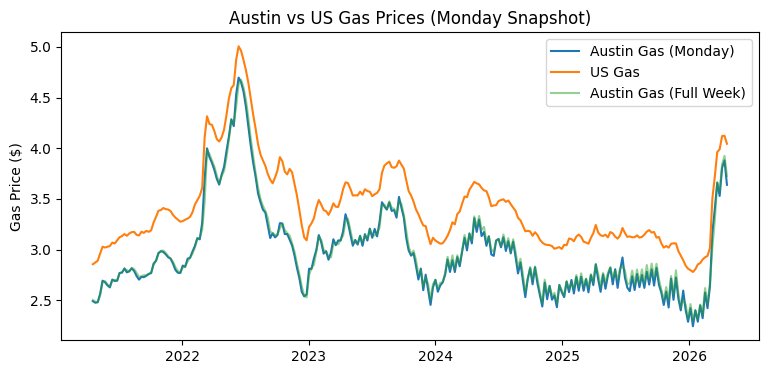

In [49]:
df_monday = pd.read_csv("Monday_Combined_dataset.csv")
df_monday["date"] = pd.to_datetime(df_monday["date"])

plt.figure(figsize=(9,4))

plt.plot(df_monday["date"], df_monday["gas_price"], label="Austin Gas (Monday)")
plt.plot(df_monday["date"], df_monday["national_gas_price"], label="US Gas")
plt.plot(df["date"], df["gas_price"], label="Austin Gas (Full Week)", alpha=0.5)

plt.title("Austin vs US Gas Prices (Monday Snapshot)")
plt.ylabel("Gas Price ($)")
plt.legend()
plt.show()

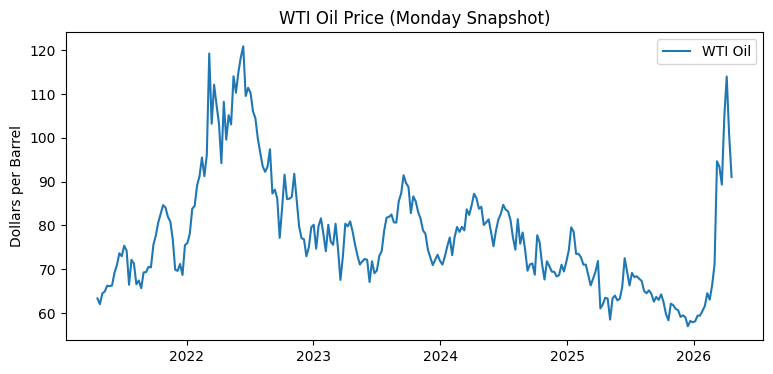

In [31]:
plt.figure(figsize=(9,4))

plt.plot(df_monday["date"], df_monday["wti_price"], label="WTI Oil")

plt.title("WTI Oil Price (Monday Snapshot)")
plt.ylabel("Dollars per Barrel")
plt.legend()
plt.show()